In [38]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
def eksak_posisi(amplitudo, g, L, t, w):
    return amplitudo * math.cos(math.sqrt(g/L) * t)

def eksak_kecepatan(amplitudo, g, L, t, w):
    return -amplitudo * math.sqrt(g/L) * math.sin(math.sqrt(g/L) * t)

def euler_kecepatan(amplitudo, g, L, t, w):
    return w + (-g * amplitudo) * t

def euler_posisi(amplitudo, g, L, t, w):
    return amplitudo + w * t

def heun_posisi(amplitudo, wi, wi2, t):
    return amplitudo + (w1 / wi2) * t

def heun_kecepatan(amplitudo, w, a1, a2, t):
    return w + ((a1 + a2) / 2) * t

w = 0
amplitudo = 0.1
L = 1
g = 9.81
t = [0.1, 0.2, 0.3, 0.4, 0.5]

def hitung_metode(fungsi_kecepatan, fungsi_posisi, w, L, g, amplitudo, t, corrector=[]):
    kecepatan_posisi = []
    for i in t:
        if corrector != []:
            pass
        else:
            w_aksen = fungsi_kecepatan(amplitudo, g, L, i, w)
            posisi_aksen = fungsi_posisi(amplitudo, g, L, i, w)
        kecepatan_posisi.append([w_aksen, posisi_aksen])
        w = w_aksen
        amplitudo = posisi_aksen

    return kecepatan_posisi

kecepatan_posisi_eksak = hitung_metode(eksak_kecepatan, eksak_posisi, w, L, g, amplitudo, t)
kecepatan_posisi_euler = hitung_metode(euler_kecepatan, euler_posisi, w, L, g, amplitudo, t)


In [40]:
table = pd.DataFrame(data=kecepatan_posisi_eksak, columns=["Kecepatan", "Posisi"])
table

,Kecepatan,Posisi
0,-0.096504,0.095135
1,-0.174685,0.077072
2,-0.194889,0.045479
3,-0.135305,0.014218
4,-0.044532,0.000068


In [41]:
table = pd.DataFrame(data=kecepatan_posisi_euler, columns=["Kecepatan", "Posisi"])
table

,Kecepatan,Posisi
0,-0.098100,0.100000
1,-0.294300,0.080380
2,-0.530858,-0.007910
3,-0.499820,-0.220253
4,0.580523,-0.470163


In [42]:
import math

# percepatan
def a(x, g, L):
    return - (g/L) * x

# --- Metode Euler ---
def euler_step(x, v, dt, g, L):
    v_new = v + a(x,g,L)*dt
    x_new = x + v*dt
    return x_new, v_new

# --- Metode Heun (improved Euler) ---
def heun_step(x, v, dt, g, L):
    # Prediksi (Euler)
    v_pred = v + a(x,g,L)*dt
    x_pred = x + v*dt
    # Koreksi
    v_new = v + 0.5*(a(x,g,L) + a(x_pred,g,L))*dt
    x_new = x + 0.5*(v + v_pred)*dt
    return x_new, v_new

# --- Metode Runge-Kutta orde 4 ---
def rk4_step(x, v, dt, g, L):
    # k untuk x adalah kecepatan, untuk v adalah percepatan
    k1x = v
    k1v = a(x,g,L)

    k2x = v + 0.5*dt*k1v
    k2v = a(x + 0.5*dt*k1x, g,L)

    k3x = v + 0.5*dt*k2v
    k3v = a(x + 0.5*dt*k2x, g,L)

    k4x = v + dt*k3v
    k4v = a(x + dt*k3x,g,L)

    x_new = x + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
    v_new = v + (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)
    return x_new, v_new

# --- Eksak ---
def exact_x(A, g, L, t):
    return A*math.cos(math.sqrt(g/L)*t)
def exact_v(A, g, L, t):
    return -A*math.sqrt(g/L)*math.sin(math.sqrt(g/L)*t)

# Fungsi umum untuk menjalankan metode iteratif
def simulate(method, x0, v0, dt, steps, g, L):
    x,v = x0,v0
    hasil=[]
    for i in range(steps):
        x,v = method(x,v,dt,g,L)
        hasil.append((x,v))
    return hasil

# Parameter
g=9.81
L=1
A=0.1
v0=0.0
dt=0.1
steps=10

# Jalankan simulasi
euler = simulate(euler_step,A,v0,dt,steps,g,L)
heun  = simulate(heun_step,A,v0,dt,steps,g,L)
rk4   = simulate(rk4_step,A,v0,dt,steps,g,L)

# Eksak pada waktu dt, 2dt, 3dt,...
exact=[(exact_x(A,g,L,(i+1)*dt),exact_v(A,g,L,(i+1)*dt)) for i in range(steps)]

print("t\tEksak x\t\tEuler x\t\tHeun x\t\tRK4 x")
for i in range(steps):
    print(f"{(i+1)*dt:.1f}\t{exact[i][0]:.6f}\t{euler[i][0]:.6f}\t{heun[i][0]:.6f}\t{rk4[i][0]:.6f}")


t	Eksak x		Euler x		Heun x		RK4 x
0.1	0.095135	0.100000	0.095095	0.095135
0.2	0.081013	0.090190	0.080621	0.081015
0.3	0.059009	0.070570	0.058009	0.059014
0.4	0.031263	0.042102	0.029512	0.031271
0.5	0.000475	0.006712	-0.002020	0.000487
0.6	-0.030359	-0.032809	-0.033424	-0.030344
0.7	-0.058239	-0.072988	-0.061544	-0.058223
0.8	-0.080453	-0.109949	-0.083547	-0.080437
0.9	-0.094838	-0.139749	-0.097205	-0.094826
1.0	-0.099995	-0.158764	-0.101127	-0.099989


In [43]:
error = {

}

def hitung_error(eksak, numerik):
    hasil_error = []
    for i in range(len(numerik)):
        hasil_error.append((numerik[i][0] - eksak[i][0]) / eksak[i][0])
    
    return hasil_error

error["euler"] = hitung_error(exact, euler)
error["heun"] = hitung_error(exact, heun)
error["rk4"] = hitung_error(exact, rk4)

In [44]:
print(error)

{'euler': [0.05113821601001681, 0.11327480736624124, 0.19592183997241658, 0.34671947255719265, 13.129126475768347, 0.08069863415591282, 0.2532491283694072, 0.3666290248360928, 0.47355992430538785, 0.5877110063988137], 'heun': [-0.0004201134852745823, -0.004846744868373336, -0.016952733940075113, -0.056011158819955185, -5.251324710813171, 0.10094855020936791, 0.05675006968150649, 0.038460621913156426, 0.024963752996152083, 0.011317484973172186], 'rk4': [1.375858349482802e-06, 2.2135092349189233e-05, 8.007798354014542e-05, 0.0002687324495899212, 0.025484774058947935, -0.000495378440314824, -0.0002822133429283997, -0.00019499546364897455, -0.0001312642728884301, -6.708788825534183e-05]}


In [45]:
print("euler", sum(error["euler"]) / len(error["euler"]))
print("heun", sum(error["heun"]) / len(error["heun"]))
print("rk4", sum(error["rk4"]) / len(error["rk4"]))

euler 1.559802852973983
heun -0.5097114982153494
rk4 0.0024686156034740706


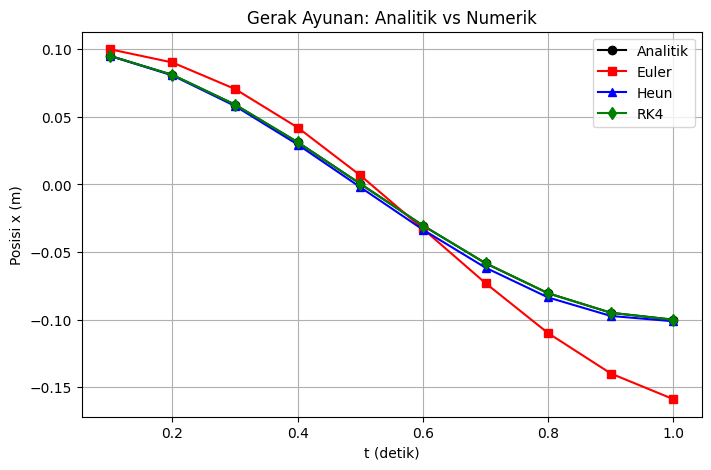

In [46]:
dt=0.1; steps=10  # dt agak besar supaya kelihatan
ts=[(i+1)*dt for i in range(steps)]



# Jalankan simulasi
euler = np.array(simulate(euler_step,A,v0,dt,steps,g,L))
heun  = np.array(simulate(heun_step,A,v0,dt,steps,g,L))
rk4   = np.array(simulate(rk4_step,A,v0,dt,steps,g,L))
exact= np.array([exact_x(A,g,L,t) for t in ts])

# Plot gaya mirip contoh kamu
plt.figure(figsize=(8,5))
plt.plot(ts, exact, 'ko-', label='Analitik')     # hitam bulat
plt.plot(ts, euler[:,0], 'rs-', label='Euler')        # merah kotak
plt.plot(ts, heun[:,0],  'b^-', label='Heun')         # biru segitiga
plt.plot(ts, rk4[:,0],   'gd-', label='RK4')          # hijau diamond

plt.xlabel('t (detik)')
plt.ylabel('Posisi x (m)')
plt.title('Gerak Ayunan: Analitik vs Numerik')
plt.grid(True)
plt.legend()
plt.show()

In [47]:
print(rk4)

[[ 0.0951351  -0.09649607]
 [ 0.08101503 -0.18360325]
 [ 0.0590136  -0.25284745]
 [ 0.0312713  -0.29749248]
 [ 0.00048714 -0.31319534]
 [-0.03034402 -0.29842876]
 [-0.05822276 -0.25462971]
 [-0.08043693 -0.18605956]
 [-0.0948255  -0.09938947]
 [-0.09998878 -0.0030514 ]]
